# 神经网络

神经网络可以使用 `torch.nn` 包来构建。<br>
既然你已经初步了解了 `autograd`，那么 `nn` 就依赖于 `autograd` 来定义模型并对其求导。`nn.Module` 包含各个层，以及一个返回 `output` 的 `forward(input)` 方法。<br>

例如，看看这个用于对手写数字图像进行分类的网络:<br>
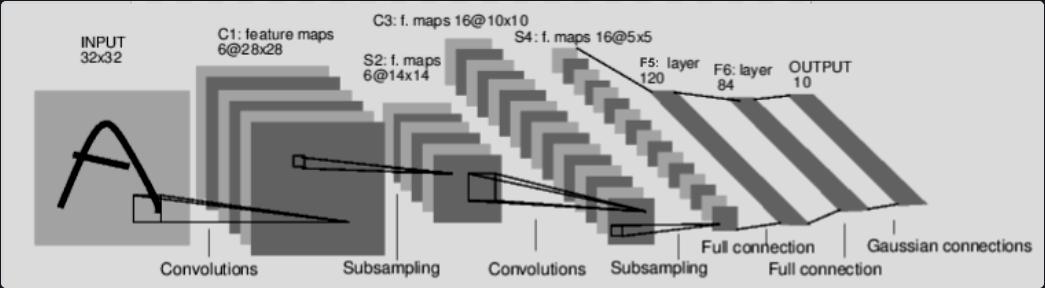 <br>
<div style="text-align:center;font-size:0.95em;color:pink;">卷积神经网络</div>

这是一个简单的前馈网络。它接收输入，将其依次通过多个层，最后给出输出。

神经网络的典型训练过程如下：

- 定义具有可学习参数（或权重）的神经网络
- 在输入数据集上进行迭代
- 通过网络处理输入
- 计算损失（输出距离目标有多远）
- 将梯度反向传播回网络的参数中
- 更新网络的权重，通常使用简单的更新规则：`权重 = 权重 - 学习率 * 梯度`

## 一. 定义网络
让我们来定义这个网络<br>

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):

    def __init__(self):
        super().__init__()
        # 1 input image channel, 6 output channels, 5x5 square convolution (1输入图像通道, 6输出通道, 5x5正方形卷积核)
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b (一个仿射操作: y = Wx + b)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 5*5 from image dimension (5*5来自图像维度)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, input):
        # Convolution layer C1: 1 input image channel, 6 output channels, (卷积层C1: 1输入图像通道, 6输出通道)
        # 5x5 square convolution, it uses RELU activation function, and (5x5正方形卷积, 它使用RELU激活函数, 并且)
        # outputs a Tensor with size (N, 6, 28, 28), where N is the size of the batch (输出一个大小为(N,6,28,28)的张量, 其中N是批处理大小)
        c1 = F.relu(self.conv1(input))
        # Subsampling layer S2: 2x2 grid, purely functional, (下采样层S2: 2x2网格, 纯函数的)
        # this layer does not have any parameter, and outputs a (N, 6, 14, 14) Tensor (这一层没有任何参数, 并且输出一个(N,6,14,14)张量)
        s2 = F.max_pool2d(c1, (2, 2))
        # Convolution layer C3: 6 input channels, 16 output channels, (卷积层C3: 6输入通道, 16输出通道)
        # 5x5 square convolution, it uses RELU activation function, and (5x5正方形卷积, 它使用RELU激活函数, 并且)
        # outputs a (N, 16, 10, 10) Tensor (输出一个(N,16,10,10)的张量
        c3 = F.relu(self.conv2(s2))
        # Subsampling layer S4: 2x2 grid, purely functional, (下采样层S4: 2x2网格, 纯函数的)
        # this layer does not have any parameter, and outputs a (N, 16, 5, 5) Tensor (这一层没有任何参数, 并且输出一个(N,16,5,5)张量)
        s4 = F.max_pool2d(c3, 2)
        # Flatten operation: purely functional, outputs a (N, 400) Tensor (一维化操作: 纯函数的, 输出一个(N,400)张量)
        s4 = torch.flatten(s4, 1)
        # Fully connected layer F5: (N, 400) Tensor input, (完全连接层F5:(N,400)张量输入)
        # and outputs a (N, 120) Tensor, it uses RELU activation function (并且输出一个(N,200)张量, 它使用RELU激活函数)
        f5 = F.relu(self.fc1(s4))
        # Fully connected layer F6: (N, 120) Tensor input, (完全连接层F6:(N,120)张量输入)
        # and outputs a (N, 84) Tensor, it uses RELU activation function (并且输出一个(N,84)张量, 它使用RELU激活函数)
        f6 = F.relu(self.fc2(f5))
        # Fully connected layer OUTPUT: (N, 84) Tensor input, and (完全连接输出:(N,84)张量输入)
        # outputs a (N, 10) Tensor (输出一个(N,10)张量)
        output = self.fc3(f6)
        return output


net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


````mermaid
flowchart LR
    subgraph FE["特征提取阶段 —— “看”图片"]
        IN["输入图像<br/>(N, 1, 32, 32)<br/>灰度图 32×32"]
        C1["C1 卷积层<br/>nn.Conv2d(1, 6, 5)<br/>c1 = F.relu(conv1(x))<br/>输出 (N, 6, 28, 28)<br/>参数: 6 个 5×5 卷积核"]
        S2["S2 下采样层(池化)<br/>s2 = F.max_pool2d(c1, (2,2))<br/>输出 (N, 6, 14, 14)<br/>无参数"]
        C3["C3 卷积层<br/>nn.Conv2d(6, 16, 5)<br/>c3 = F.relu(conv2(s2))<br/>输出 (N, 16, 10, 10)<br/>参数: 16 个 5×5 卷积核"]
        S4["S4 下采样层(池化)<br/>s4 = F.max_pool2d(c3, 2)<br/>输出 (N, 16, 5, 5)<br/>无参数"]
    end
    subgraph CL["分类阶段 —— “想”是什么数字"]
        FL["Flatten 展平<br/>s4 = torch.flatten(s4, 1)<br/>输出 (N, 400)<br/>把 16×5×5 拉直成一条"]
        F5["F5 全连接层<br/>nn.Linear(400, 120)<br/>f5 = F.relu(fc1(s4))<br/>输出 (N, 120)"]
        F6["F6 全连接层<br/>nn.Linear(120, 84)<br/>f6 = F.relu(fc2(f5))<br/>输出 (N, 84)"]
        OUT["OUTPUT 输出层<br/>nn.Linear(84, 10)<br/>输出 (N, 10)<br/>10 个数字的分数"]
    end
    IN --> C1 --> S2 --> C3 --> S4
    S4 --> FL
    FL --> F5 --> F6 --> OUT
````

````text
输入图像    (1, 1, 32, 32)
C1 卷积     (1, 6, 28, 28)     ← 32-5+1=28
S2 池化     (1, 6, 14, 14)
C3 卷积     (1, 16, 10, 10)    ← 14-5+1=10
S4 池化     (1, 16, 5, 5)
Flatten     (1, 400)           ← 16×5×5=400
F5 全连接   (1, 120)
F6 全连接   (1, 84)
输出        (1, 10)
````

### Questions {1}:
- 1. 几个卷积层?
     
     **2 个**(conv1、conv2)<br>
     > 严格说,这个网络有 **5 个"带参数的层"**:2 个卷积层 + 3 个全连接层(`fc1/fc2/fc3`)。<br>
     > "卷积层"就是 C1 和 C3 这两个。池化层 S2/S4 没有参数,不算"带权重的层"。<br>
     
- 2. 中间连接的是下采样层吗?
     
     **是,而且是交替结构**<br>
     > 完整链条就是 **卷积 → 池化 → 卷积 → 池化**,循环交替:<br>
     > ````text
     > C1 卷积 → S2 池化 → C3 卷积 → S4 池化 → Flatten → F5→F6→OUT
     > ````
     > `下采样=池化`, 其实就是作总结, 教程使用`.max_pool2d`即<最大池化>

- 3. `nn.Conv2d(6, 16, 5)` 的含义?

     > - `6` = 输入通道数(上一层的输出是 6 通道)
     > - `16` = 输出通道数(本层产出 16 张特征图 = 16 个卷积核)
     > - `5` = 卷积核边长(5×5 正方形)

     补两个默认参数:没写的 `stride=1`(滑动步长 1)、`padding=0`(不补边)。<br>
     所以输出边长 = 输入 − 5 + 1。<br>
     
- 4. 为什么是正方形卷积核, 而不是长方形?

     > 1. **各向同性**:横竖方向的感受野对称,设计超参时省心(一个数 `5` 就可以,不用纠结 3×7 还是 7×3);
     > 2. **通用性强**:图片的纹理特征横竖都可能出现,正方形核都能捕捉。

     但**长方形核在真实模型里确实存在**,而且有明确用途.<br>
     比如竖直条纹用 1×N 的水平长条核、水平条纹用 N×1 的垂直长条核,一个核就覆盖很长的纹理,比叠几个正方形核更省参数。<br>
     经典案例是 2017 年的 Inception-v3,把大正方形核**拆成两个长方形核**(比如 5×5 → 3×3 + 3×3 或 1×N + N×1),既省计算又能加深网络。<br>

- 5. 展平后进行分类, 类似决策树是吗?

     理解为"展平一维化 → 交给分类"有些对, 不过又有点不对.
     主要是神经元 ≠ 决策树的分支,差别在这里:
     > |          | 决策树               | 神经网络全连接层                  |
     > | -------- | -------------------- | --------------------------------- |
     > | 判断方式 | 一串 if-else         | 加权求和 `y = Wx + b` + 激活函数  |
     > | 分类边界 | **轴平行的矩形**硬切 | **平滑曲线/曲面**(可旋转、可弯曲) |
     > | 数学性质 | 不可导(不能梯度下降) | 处处可导(靠 backward 训练)        |

     对于一个二维散点图,两类数据需要斜着分开.<br>
     - 决策树只能用"横一刀 + 竖一刀"的阶梯去逼近,<br>
     - 而全连接层的边界是一条斜直线,一步到位。<br>
     
     因此神经网络能学出更灵活的分类。<br>

你只需要定义 `forward` 函数，而 `backward` 函数（计算梯度的地方）会自动通过 `autograd` 为你定义。你可以在 `forward` 函数中使用任何张量操作。

模型的可学习参数由 `net.parameters()` 返回

In [17]:
params = list(net.parameters())
print(len(params))
print(params[0].size())  # conv1's .weight

10
torch.Size([6, 1, 5, 5])


### Questions {2}:
- 1. Q1: `len(params)` 为什么是 10,而不是 11?<br>
     
     因为 `len(params)` 数的是**"参数张量"的个数**,不是层数,也不是张量的维度数。<br>

     每个"带参数的层"都贡献 **2 个张量**:一个权重 `weight` + 一个偏置 `bias`。5 个层 × 2 = **10**:
     > | 索引 | 层    | 权重       | 偏置   |
     > | ---- | ----- | ---------- | ------ |
     > | 0,1  | conv1 | (6,1,5,5)  | (6,)   |
     > | 2,3  | conv2 | (16,6,5,5) | (16,)  |
     > | 4,5  | fc1   | (120,400)  | (120,) |
     > | 6,7  | fc2   | (84,120)   | (84,)  |
     > | 8,9  | fc3   | (10,84)    | (10,)  |
     
     **你的"8+3=11"错在哪**:

     > 你把 conv 权重是个**4 维张量**这件事,误当成了"它算 4 个参数"(于是 4+4=8);又把三个 fc 层当成"每层只算 1 个"(再 +3)。但:<br>
     > - "4 维"说的是这一个张量内部有 4 个维度,**不是**它只值 4 个参数——`(6,1,5,5)` 里实际装了 6×1×5×5 = 150 个数;<br>
     > - 每个 fc 层也不是 1 个张量,而是 weight + bias **2 个**。<br>
    
     正确的数法是:**每层固定 = 权重 1 个 + 偏置 1 个 = 2 个张量** → 5×2 = 10。

- 2. Q2: `params[0]` 为什么是 `(6, 1, 5, 5)`,而不是 `(1, 6, 5, 5)`?
     
     PyTorch 卷积权重的存放顺序是固定的:<br>
     ````text
     (输出通道数, 输入通道数, 核高, 核宽)   = (out_ch, in_ch, kH, kW)
     ````

     > - **第 0 维 `6`** = 输出通道数 = **卷积核的个数**(6 个核)<br>
     > - **第 1 维 `1`** = 每个核要"看"的输入通道数(这里输入只有 1 个通道)<br>
     > - **后两维 `5×5`** = 核的尺寸<br>

- 3. Q3:为什么` 6 `要排在第` 0 `维?
     
     为了方便取用.<br>
     > 当要取"第 o 个输出通道的核",直接 `weight[o]` 即可拿到一个 `(in_ch, 5, 5)` 的核。<br>
     > 如果顺序反了(像你说的 `[1,6,5,5]`),每次取核都得做转置,代码就很别扭。这是 PyTorch 定的约定(和 Caffe 一致)。<br>
     
     不过, 另一个主流框架 TensorFlow 用的顺序**完全相反**(`(kH, kW, in_ch, out_ch)`),同一个模型换框架,权重就得"倒着读"。<br>
     这纯粹是各家习惯不同,没有对错。<br>

让我们尝试一个随机的 32x32 输入。注意：此网络（LeNet）预期的输入尺寸为 32x32。要在 MNIST 数据集上使用此网络，请将数据集中的图像调整为 32x32。

In [18]:
input = torch.randn(1, 1, 32, 32)
out = net(input)
print(out)

tensor([[-0.0815,  0.0792,  0.0241,  0.0315, -0.0289,  0.0435, -0.0627, -0.0315,
         -0.0583,  0.0572]], grad_fn=<AddmmBackward0>)


### Questions {3}:
> 要在 MNIST 数据集上使用此网络，请将数据集中的图像调整为 32x32。

- 1. Q1:*MINIST*是个什么?

     **MNIST**(Modified National Institute of Standards and Technology,美国国家标准与技术研究院"改造版")——是深度学习最著名的手写数字数据集。<br>
     **7 万张 28×28 的灰度小图,内容是 0~9 的手写阿拉伯数字**:<br>

     > | 项目       | 值                                          |
     > | ---------- | ------------------------------------------- |
     > | 图片尺寸   | 28×28 像素,灰度(1 个通道)                   |
     > | 类别       | 10 个(数字 0~9)                             |
     > | 训练集     | 60,000 张(就是 demo 下载的那个)             |
     > | 测试集     | 10,000 张                                   |
     > | 单张数据量 | 28×28 = 784 个像素,每个像素 0~255(灰度深浅) |

     **名字由来**:它源自 NIST 扫描的手写样本,LeCun(又是他,LeNet 作者)团队 1998 年把它清理改造成这个标准版本,专门给当时刚起步的神经网络做评测。

- 2. Q2:为何要调整为32x32?

     > Attention:<br>
     > MNIST 的尺寸是 **28×28**,但此网络的输入是 **32×32**(C1 用 5×5 卷积,32→28,一路算下来最后才是 400 维)。<br>
     
     如果直接把 28×28 喂进去:<br>
     ````text
     28 → 卷积5 → 24 → 池化 → 12 → 卷积5 → 8 → 池化 → 4 → 展平 16×4×4 = 256 ≠ 400  ✗
     ````
     <br>
     `fc1` 期望 400,却收到 256,直接报错。所以**要用 MNIST 训练这个 LeNet,得先把它 resize 成 32×32**(或者改 fc1 的输入维度)。<br>
     这是训练时最常见的第一个 bug.<br>

将所有参数的梯度缓冲区置零，并使用随机梯度进行反向传播

In [19]:
net.zero_grad()
out.backward(torch.randn(1, 10))

> Attention:<br>
> `torch.nn` 仅支持小批量（mini-batches）。整个 `torch.nn` 包仅支持作为样本小批量的输入，而不支持单个样本。<br>

例如，`nn.Conv2d` 将接收一个 4D 张量，格式为 `样本数 x 通道数 x 高 x 宽`。<br>
如果你只有一个样本，只需使用 `input.unsqueeze(0)` 来添加一个伪批处理维度。<br>

### Questions {4}:
- 1. Q1: 什么是`.unsqueeze(0)`?

     **`unsqueeze` = "插入一个大小为 1 的维度"**,括号里的 `0` 表示**插在最前面(位置 0)**。比如:\
     
     > ````text
     > (1, 32, 32)  --unsqueeze(0)-->  (1, 1, 32, 32)
     > ````
     
     形状从 3 维变 4 维,**在最前面多了一个 `1`**。<br>
     注意:`squeeze(0)` 是它的逆操作,把那个 1 去掉,形状又变回去。<br>

- 2. Q2: 为什么要这样添加一个维度?岂不是多此一举?

     并不是多此一举, 而是`torch.nn`的卷积层(`nn.Conv2d`、`nn.MaxPool2d`……)有硬性要求:<br>
     
     **必须接受 (N, C, H, W) 四维的"小批量"格式**<br>
     而`N` 是批次里有多少张图。<br>

     所以必须要手动添加一个`N`进来, 即使`N`=1.

在继续深入之前，让我们回顾一下目前为止所见的所有类。

- **回顾**
  - `torch.Tensor` - 一个支持自动求导操作（如 `backward()`）的*多维数组*。同时*保存有关该张量的梯度*。
  - `nn.Module` - 神经网络模块。*封装参数的便捷方式*，并提供将参数移动到 GPU、导出、加载等的辅助方法。
  - `nn.Parameter` - 一种张量，当它被分配为 `Module` 的属性时，会被*自动注册为参数*。
  - `autograd.Function` - 实现*自动求导操作的前向和反向定义*。每个 `Tensor` 操作至少创建一个 `Function` 节点，该节点连接到创建 `Tensor` 的函数，并*对其历史记录进行编码*。
  <br>

- **目前为止，我们已经涵盖了：**
  - 定义神经网络
  - 处理输入并调用反向传播
  <br>

- **尚未学习：**
  - 计算损失
  - 更新网络权重
  <br>

## 二. 损失函数

损失函数接收 (output, target) 对作为输入，并计算一个值来评估输出距离目标有多远。

nn 包下有几种不同的 [损失函数](https://pytorch.ac.cn/docs/nn.html#loss-functions)。一种简单的损失是：`nn.MSELoss`，它计算输出和目标之间的均方误差。

例如

In [20]:
output = net(input)
target = torch.randn(10)  # a dummy target, for example (一个假目标, 作为例子)
target = target.view(1, -1)  # make it the same shape as output (使其与输出对齐)
criterion = nn.MSELoss()

loss = criterion(output, target)
print(loss)

tensor(0.7540, grad_fn=<MseLossBackward0>)


现在，如果你使用 `loss` 的 `.grad_fn` 属性沿着反向路径跟踪，你会看到一个计算图，如下所示：
````text
input -> conv2d -> relu -> maxpool2d -> conv2d -> relu -> maxpool2d
      -> flatten -> linear -> relu -> linear -> relu -> linear
      -> MSELoss
      -> loss
````
因此，当我们调用 `loss.backward()` 时，整个图都会相对于神经网络参数进行求导，图中所有 `requires_grad=True` 的张量都将累积其梯度到 `.grad` 张量中。

为了说明，让我们跟踪几个反向步骤

### Questions {5}
- 1. Q1:不是已经 10 个元素了吗?为何要对齐?
     
     **没错,元素数是 10,但它是一维的 `(10,)`;而网络的输出是二维的 `(1, 10)`。<br>
     ** `view` 要解决的**不是元素个数**,而是**形状/维数**——给 target 补一个"批次维度 1",让两者形状严格一致。<br>

     > 我们来看一下形状:
     > ````text
     > output:  (1, 10)    ← 网络吐出来的, 带批次维
     > target:  (10,)      ← 假 target, 没批次维  ← 形状不一样!
     > target:  (1, 10)    ← view(1,-1) 之后, 对上 ✓
     > ````

- 2. Q2:`.view(1, -1)`是把数据对齐至(-1,1)区间吗?
     
     不是, 它不会改变元素大小.<br>
     我们来看`.view()`到底是干嘛的:<br>

     > ````text
     > target 原来是:  (10,)               ← 1 维, 10 个元素
     > view(1, -1) 后: (1, 10)             ← 2 维, 还是 10 个元素
     > ````
     > - `1` = 第 0 维大小是 1(这就是"批次维度")
     > - `-1` = **占位符 / 通配符**:"这维该多大,由torch自行计算"
     > - 但是必须要保证调整之后, 所有维度元素之积=原元素总量

     更多例子:
     > 假设target为(6,)<br>
     > 则`view(2,-1)`→(2,3),<br>
     > `view(-1,2)`→(3,2),<br>
     > `view(6,-1)`→(6,1)。<br>
     > **`-1` 每次都自动算出"剩下的那个维",保证 6 个元素一个不多一个不少。**<br>

- 3. Q3:那这样`.view(1,-1)`和之前的`.unsqueeze(0)`不是一样的吗?

     是的, 其实在这里完全是等价的, 可以换着用, 没有问题.

     它们的差别在于`.view()`可以比`.unsqueeze(0)`更灵活地调整维度:
     > ````text
     > 同一个6元素张量:
     > view(-1, 2)  -> (3, 2)   <- view 是"通用整形",能摆出任意形状
     > unsqueeze(0) -> (1, 6)   <- unsqueeze 只会"在最前面插个1"
     > ````
     > - **`view`** = 通用重塑工具,可以把 6 个元素排成 2×3、3×2、6×1……只要总元素数不变
     > - **`unsqueeze`** = 专用小工具,只干一件事:在指定位置插入一个大小为 1 的维度
     
     在这个例子里,需求恰好就是"插一个批次维",两者殊途同归。<br>
     教程注释写的是 "make it the same shape as output"(让形状和输出对齐),用 `view` 在语义上更贴合"对齐形状"这个意图,仅此而已。<br>

In [21]:
print(loss.grad_fn)  # MSELoss
print(loss.grad_fn.next_functions[0][0])  # Linear
print(loss.grad_fn.next_functions[0][0].next_functions[0][0])  # ReLU

### Questions {6}
- 1. Q1:`.grad_fn` 是什么?
     
     **功能**:一张"出生证明"。任何由**运算**产生的张量,身上都挂着它,记录"我是被哪个操作造出来的"。<br>
     反向传播时,它就是这个操作的**求导器**,知道如何把梯度算回给它的输入。<br>
     
     > - 只有**运算结果**张量有:乘法→`MulBackward0`、加法→`AddBackward0`、卷积→`ConvolutionBackward0`、全连接→`AddmmBackward0`、MSE 损失→`MseLossBackward0`、求和→`SumBackward0`、展平→`ViewBackward0`……
     > - **原料(叶子)没有**:`a.grad_fn = None`(输入 x、网络参数 weight/bias 都属于叶子)
     > - 命名规律:`<操作名>Backward<N>` = "该操作的求导器"
     
     **内部结构**:一个 grad_fn 对象 = 计算图里的**一个节点**。它本身知道自己是什么操作,并持有 `next_functions` 指向自己的输入。

- 2. Q2:`.next_functions` 是什么?

     **功能**:记录"**我这个操作的输入们,分别是谁(哪个更上游的操作)造出来的**"。反向传播的**路标**:梯度从输出流向输入,每到一个节点就问"梯度该传给谁",答案就是它记的输入们。取名 next = 反向遍历顺序里"下一个要处理的函数"。<br>
     **内部结构**:一个**列表**,长度 = 该操作的输入个数。每一项是 **(上游grad_fn, 输出编号)** 的二元组:<br>
      
     > ````text
     > next_functions[i]   = 第 i 个输入对应的元组
     > next_functions[i][0] = 造出第 i 个输入的那个上游函数
     > next_functions[i][1] = 该输入在上游操作里的输出编号(日常用不上)
     > ````

     三种特殊项:
     
     | 输入类型            | 元组里是什么          | 例子                                                         |
     | ------------------- | --------------------- | ------------------------------------------------------------ |
     | 常数                | `(None, 0)`           | `d = c + 1` 里的 `1`                                         |
     | 叶子张量(参数/输入) | `(AccumulateGrad, 0)` | 偏置、权重、输入 x——AccumulateGrad 是叶子的"梯度口袋",负责把梯度写进 `.grad` |
     | 另一个运算结果      | 那个操作的 grad_fn    | 可以继续追                                                   |
     
     **下标规则**:`next_functions` 的顺序 = **该操作被调用时参数的顺序**。

- 3. Q3:原教程注释为何错?怎么改?
     
     原教程:
     ````python
     print(loss.grad_fn)                                     # MSELoss
     print(loss.grad_fn.next_functions[0][0])                # Linear
     print(loss.grad_fn.next_functions[0][0].next_functions[0][0])   # ReLU  ← 错
     ````
     <br>
     
     真实输出(torch 2.13 实测):
     ````text
     MseLossBackward0
     AddmmBackward0
     AccumulateGrad        ← 不是 ReLU!
     ````

     > **原因**:全连接 `Linear` 内部实现为 `addmm(bias, input, weight)`(即 `y = x·Wᵀ + b`)。它的参数顺序是 **(bias, input, weight)**,**偏置排在第 0 位**。偏置是叶子参数 → 在图中以 `AccumulateGrad` 存在。所以 `[0][0]` 追的是**偏置支路**,
     一步撞上叶子口袋,永远追不到数据。教程注释 `# ReLU` 是作者按"数据路径"的直觉写的,**与真实下标对不上**(过时/笔误)。
     
     **正确改法**:数据是 Addmm 的**第 1 个输入**,所以第二个 `[0]` 改成 `[1]`:
     ````python
     print(loss.grad_fn)                                              # MseLossBackward0
     print(loss.grad_fn.next_functions[0][0])                         # AddmmBackward0 (fc3)
     print(loss.grad_fn.next_functions[0][0].next_functions[1][0])    # ReluBackward0
     ````
     
     **为什么这么改**:每一步 `[i]` 选的是"第 i 个输入"。MSE 的第 0 输入是 out(用 `[0]`,对);Addmm 的数据在第 1 位(用 `[1]`)。改完就能沿数据路径追:Relu → fc2 → Relu → fc1 → flatten → 池化 → conv……

````mermaid
flowchart TD
    classDef spine fill:#d1fae5,stroke:#059669
    classDef leaf fill:#fef3c7,stroke:#d97706
    classDef trap fill:#fee2e2,stroke:#ef4444,stroke-width:2px

    %% ========== 数据主干(前向: 从左到右) ==========
    x["输入 x<br/>(叶子, 无 grad_fn)"]
    C1["C1 卷积<br/>ConvolutionBackward0"]
    R1["ReLU<br/>ReluBackward0"]
    S2["S2 池化<br/>MaxPool2DWithIndices<br/>Backward0"]
    C3["C3 卷积<br/>ConvolutionBackward0"]
    R3["ReLU<br/>ReluBackward0"]
    S4["S4 池化<br/>MaxPool2DWithIndices<br/>Backward0"]
    FL["Flatten 展平<br/>ViewBackward0"]
    F5["F5 全连接<br/>AddmmBackward0"]
    R5["ReLU<br/>ReluBackward0"]
    F6["F6 全连接<br/>AddmmBackward0"]
    R6["ReLU<br/>ReluBackward0"]
    F7["OUT 全连接<br/>AddmmBackward0"]
    L["MSE 损失<br/>MseLossBackward0"]
    loss["loss 张量"]

    x -->|"[0] 数据"| C1
    C1 --> R1
    R1 --> S2
    S2 --> C3
    C3 --> R3
    R3 --> S4
    S4 --> FL
    FL -->|"[1] 数据"| F5
    F5 --> R5
    R5 --> F6
    F6 --> R6
    R6 -->|"[1] 数据 ✅"| F7
    F7 --> L
    L --> loss

    %% ========== 叶子参数 ==========
    c1w["conv1.weight<br/>AccumulateGrad"]
    c1b["conv1.bias<br/>AccumulateGrad"]
    c2w["conv2.weight<br/>AccumulateGrad"]
    c2b["conv2.bias<br/>AccumulateGrad"]
    f5w["fc1.weight<br/>AccumulateGrad"]
    f5b["fc1.bias<br/>AccumulateGrad"]
    f6w["fc2.weight<br/>AccumulateGrad"]
    f6b["fc2.bias<br/>AccumulateGrad"]
    f7w["fc3.weight<br/>AccumulateGrad"]
    f7b["fc3.bias<br/>AccumulateGrad"]

    C1 -->|"[1] 权重"| c1w
    C1 -->|"[2] 偏置"| c1b
    C3 -->|"[1] 权重"| c2w
    C3 -->|"[2] 偏置"| c2b
    F5 -->|"[0] 偏置"| f5b
    F5 -->|"[2] 权重"| f5w
    F6 -->|"[0] 偏置"| f6b
    F6 -->|"[2] 权重"| f6w
    F7 -->|"[0] 偏置 ❌ 教程追到这"| f7b
    F7 -->|"[2] 权重"| f7w

    class x,C1,R1,S2,C3,R3,S4,FL,F5,R5,F6,R6,F7,L,loss spine
    class c1w,c1b,c2w,c2b,f5w,f5b,f6w,f6b,f7w leaf
    class f7b trap
````

## 三. 反向传播

要反向传播误差，我们所要做的就是 `loss.backward()`。不过你需要清除现有的梯度，否则梯度会累积到现有的梯度上。

现在我们将调用 `loss.backward()`，并观察 conv1 的偏置梯度在反向传播前后的变化。由于我们还没有引入优化器，我们直接在模型上清除梯度。一旦使用优化器，建议使用如下所示的 `optimizer.zero_grad()`。

In [22]:
net.zero_grad()     # zeroes the gradient buffers of all parameters (清零所有参数的梯度缓冲)

print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)

loss.backward()

print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)

conv1.bias.grad before backward
None
conv1.bias.grad after backward
tensor([ 0.0025,  0.0019,  0.0016,  0.0090,  0.0071, -0.0005])


现在，我们已经了解了如何使用损失函数。

**延伸阅读**

> 神经网络包包含各种模块和损失函数，它们构成了深度神经网络的构建块。完整的文档列表在 [这里](https://pytorch.ac.cn/docs/nn)。

**剩下要学习的唯一一件事是：**

> - 更新网络权重

## 四. 更新权重

实践中使用的最简单的更新规则是随机梯度下降 (SGD)

````text
weight = weight - learning_rate * gradient
````

我们可以使用简单的 Python 代码实现这一点

````python
learning_rate = 0.01
for f in net.parameters():
    with torch.no_grad():
        f -= f.grad * learning_rate
````

然而，当你在使用神经网络时，你会想要使用各种不同的更新规则，例如 SGD、Nesterov-SGD、Adam、RMSProp 等。为了实现这一点，我们构建了一个小包：`torch.optim`，它实现了所有这些方法。使用它非常简单：

In [23]:
import torch.optim as optim

# create your optimizer
optimizer = optim.SGD(net.parameters(), lr=0.01)

# in your training loop:
optimizer.zero_grad()   # zero the gradient buffers
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()    # Does the update

> Attention:<br>
> 观察如何使用 `optimizer.zero_grad()` 手动将梯度缓冲区置零。这是因为梯度会累积，如 [反向传播](https://docs.pytorch.ac.cn/tutorials/beginner/blitz/neural_networks_tutorial.html#backprop) 部分所述。<br>